# CCO05: Redo everything with updated gene labels

## since Aug 28:
 - <s>still need to remove endothelial cells from heart samples</s>
 - <s>line up barplot and dotplot</s>
 - <s>fix umap color glitch</s>
 - <s>cell-cell communication</s>
 - new maturation markers: MYH7, MYH6, TNNT2, ACTC1, GJA1, NKX2-5, SERCA2, PLN, RBM20, MYL2, MYL3, DES, ZFHX3, HCN4, RYR2, KCNJ2, TBX5, MEF2C, GATA4, SRF, SLC8A1, CAV3, MYBPC3, MYH11, CDH2, TRDN, CML, NPR3, SYNPO, ACTN2, LDB3, CCL2, SPTBN1, GATA6, MMP9, TNNI3, MEF2A, TBX20, ANKRD1, GATA1, CYP11B2, and WNT11
 - <s>cluster 15 is cardiomyocytes</s>

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import glob
import scipy

In [6]:
# %%bash
# rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO05
# mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO05

In [3]:
DATA_DIR = '/home/herbert/PyProjects/cocultured_organ/data/240603'
PREV_DIR = '/home/herbert/PyProjects/cocultured_organ/workspace/CCO04'
WORK_DIR = '/home/herbert/PyProjects/cocultured_organ/workspace/CCO05'

## 1. Coembed and Cluster - Using CCO04

In [4]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/adata

In [7]:
for i, f in enumerate(glob.glob(f'{PREV_DIR}/coembed/*.h5ad')):
    sample_name = f.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f)
    adata.write(f'{WORK_DIR}/adata/{sample_name}.h5ad')

### 1.1 remove cluster 4 from HO and CM3O

In [15]:
adata = sc.read_h5ad(f'{WORK_DIR}/adata/SC160__HO-JW-052224.h5ad')
print(f"Removing {(adata.obs['leiden'] == '4').sum()} cells from HO")
adata[adata.obs['leiden'] != '4'].write(f'{WORK_DIR}/adata/SC160__HO-JW-052224.h5ad')

adata = sc.read_h5ad(f'{WORK_DIR}/adata/SC160__CM3O-JW-052224.h5ad')
print(f"Removing {(adata.obs['leiden'] == '4').sum()} cells from CM3O")
adata[adata.obs['leiden'] != '4'].write(f'{WORK_DIR}/adata/SC160__CM3O-JW-052224.h5ad')

Removing 76 cells from HO
Removing 69 cells from CM3O


### 1.2 plot umap while fix the color clitch

In [45]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/umap

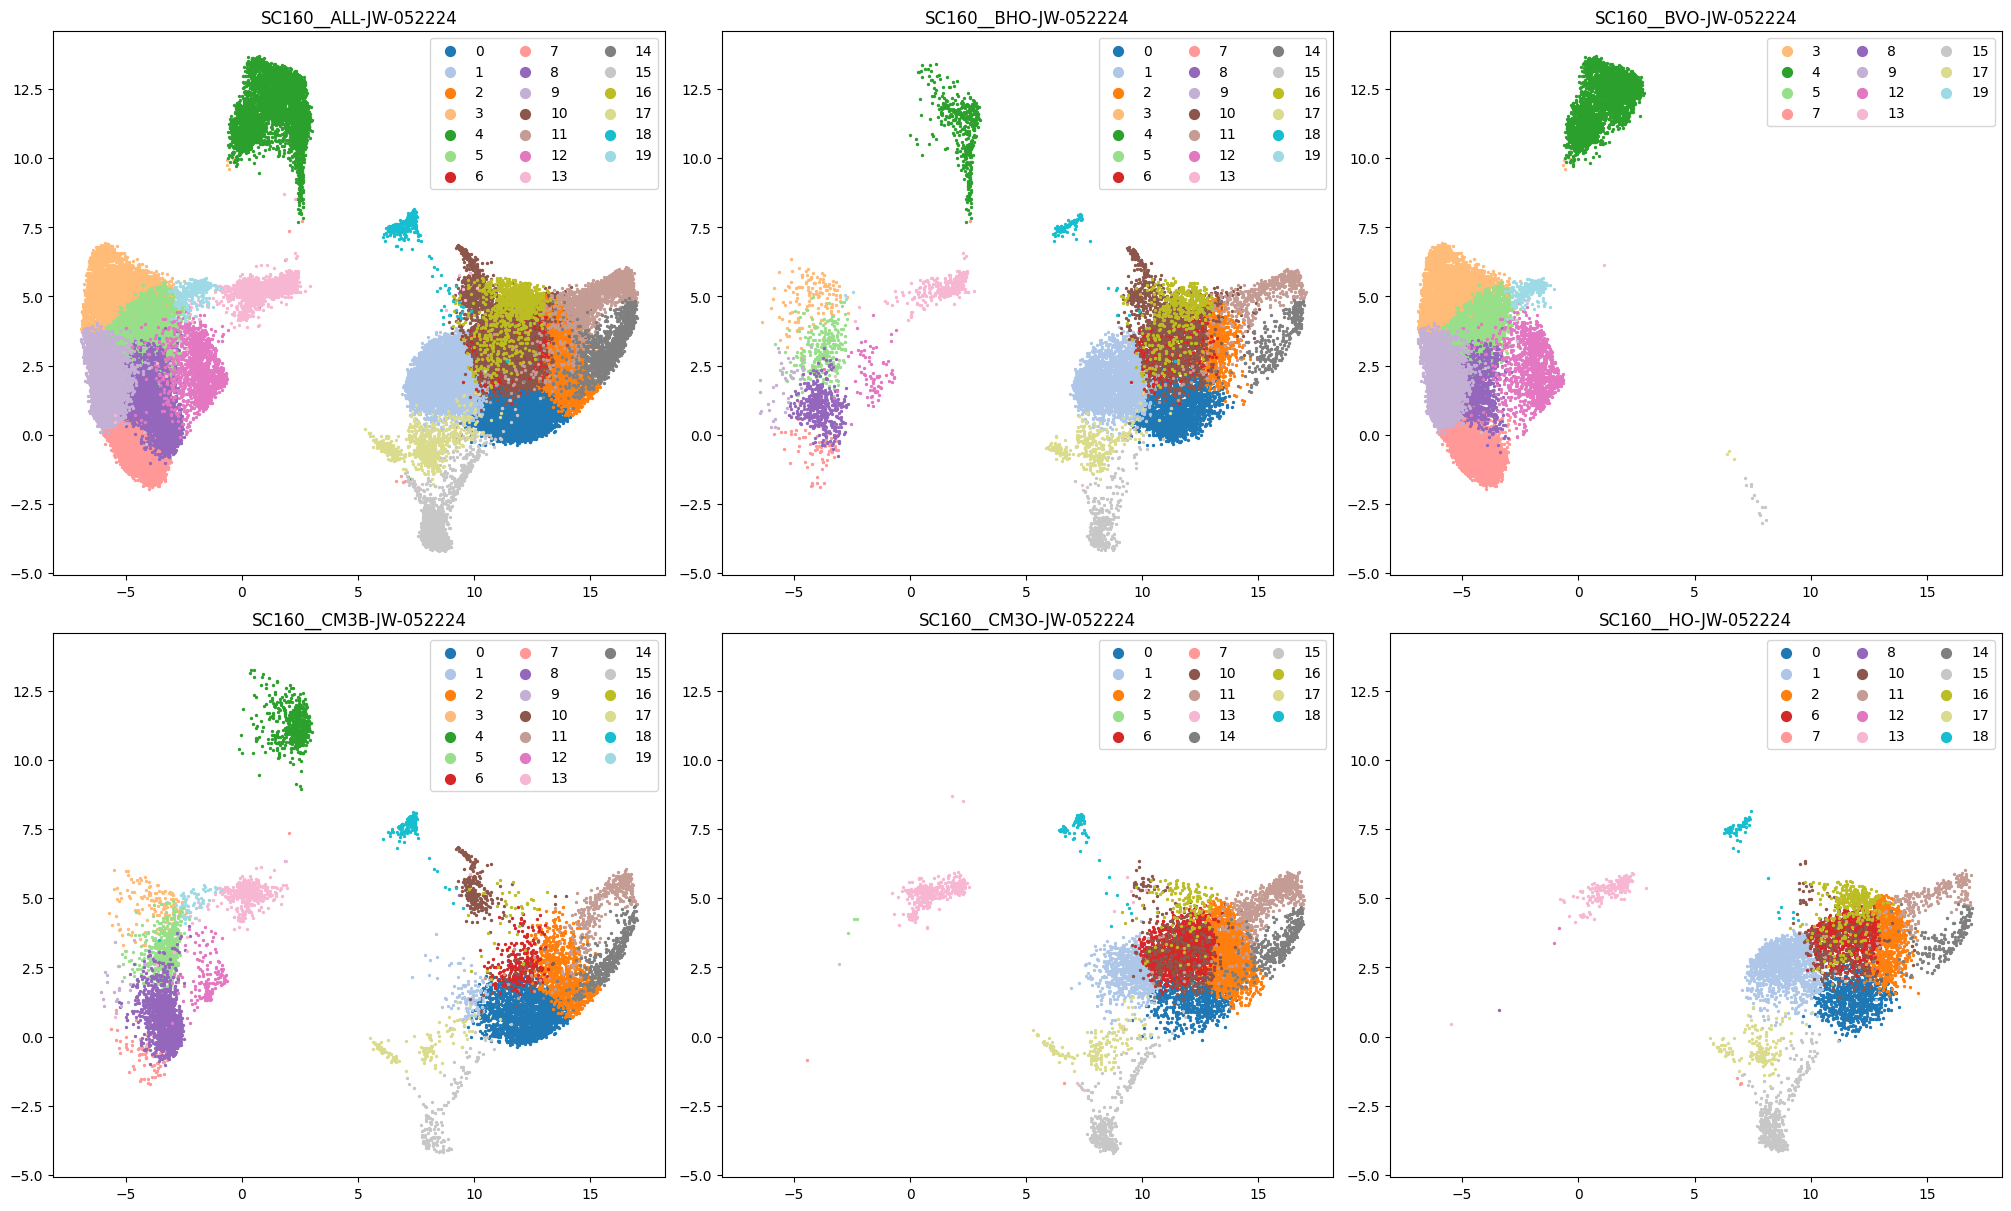

In [62]:
# %%capture --no-display

colors = plt.get_cmap('tab20').colors
fig, axs = plt.subplots(2, 3, figsize=(20,12), layout="constrained")
axs = axs.flatten()

for i, f in enumerate(glob.glob(f'{WORK_DIR}/adata/*.h5ad')):
    sample_name = f.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(f)
    # sc.tl.pca(adata, svd_solver='arpack')
    # sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
    # sc.tl.leiden(adata, resolution=0.5)
    # adata.write(f'{OUT_DIR}/coembed/{sample_name}.h5ad.clustered')
    
    # axs[i] = sc.pl.umap(adata, color='leiden', ax=axs[i], title=sample_name, show=False, cmap='tab10')
    for j in range(0, 20):
        if (adata.obs['leiden'] == str(j)).sum() > 0:
            axs[i].scatter(adata.obsm['X_umap'][adata.obs['leiden'] == str(j), 0], 
                           adata.obsm['X_umap'][adata.obs['leiden'] == str(j), 1], 
                           color=colors[j], s=2, label=str(j))
            
    axs[i].legend(ncol=3, loc='upper right', markerscale=5)
    axs[i].set_title(sample_name)
        
    if i == 0:
        xlim_ref = axs[i].get_xlim()
        ylim_ref = axs[i].get_ylim()
    else:
        axs[i].set_xlim(xlim_ref)
        axs[i].set_ylim(ylim_ref)
    
plt.savefig(f'{WORK_DIR}/adata/umaps.png')
plt.show()

In [58]:
colors[19]

(0.8705882352941177, 0.6196078431372549, 0.8392156862745098)

In [24]:
# adata.concatenate(adata[-1,:])

## 2. Visualize marker positive cells

In [25]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/gene_marker_umap

In [28]:
%%capture --no-display

marker_genes = ['PECAM1', 'CDH5', 'PDGFRB', 'ACTA2', 'TAGLN', 'TNNI1', 'TNNC1', 'TNNT2', 'ACTC1']

for gene in marker_genes:

    try:
        
        fig, axs = plt.subplots(2, 3, figsize=(15,6), layout="constrained")
        axs = axs.flatten()

        for i, f in enumerate(glob.glob(f'{WORK_DIR}/adata/*.h5ad')):
            sample_name = f.split('/')[-1].strip('.h5ad')
            adata = sc.read_h5ad(f)
            axs[i] = sc.pl.umap(adata, color=gene, ax=axs[i], title=sample_name, show=False)
            if i == 0:
                xlim_ref = axs[i].get_xlim()
                ylim_ref = axs[i].get_ylim()
            else:
                axs[i].set_xlim(xlim_ref)
                axs[i].set_ylim(ylim_ref)

        plt.savefig(f'{WORK_DIR}/gene_marker_umap/{gene}.png')
    
    except:
        continue
        
    finally:
        plt.close()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

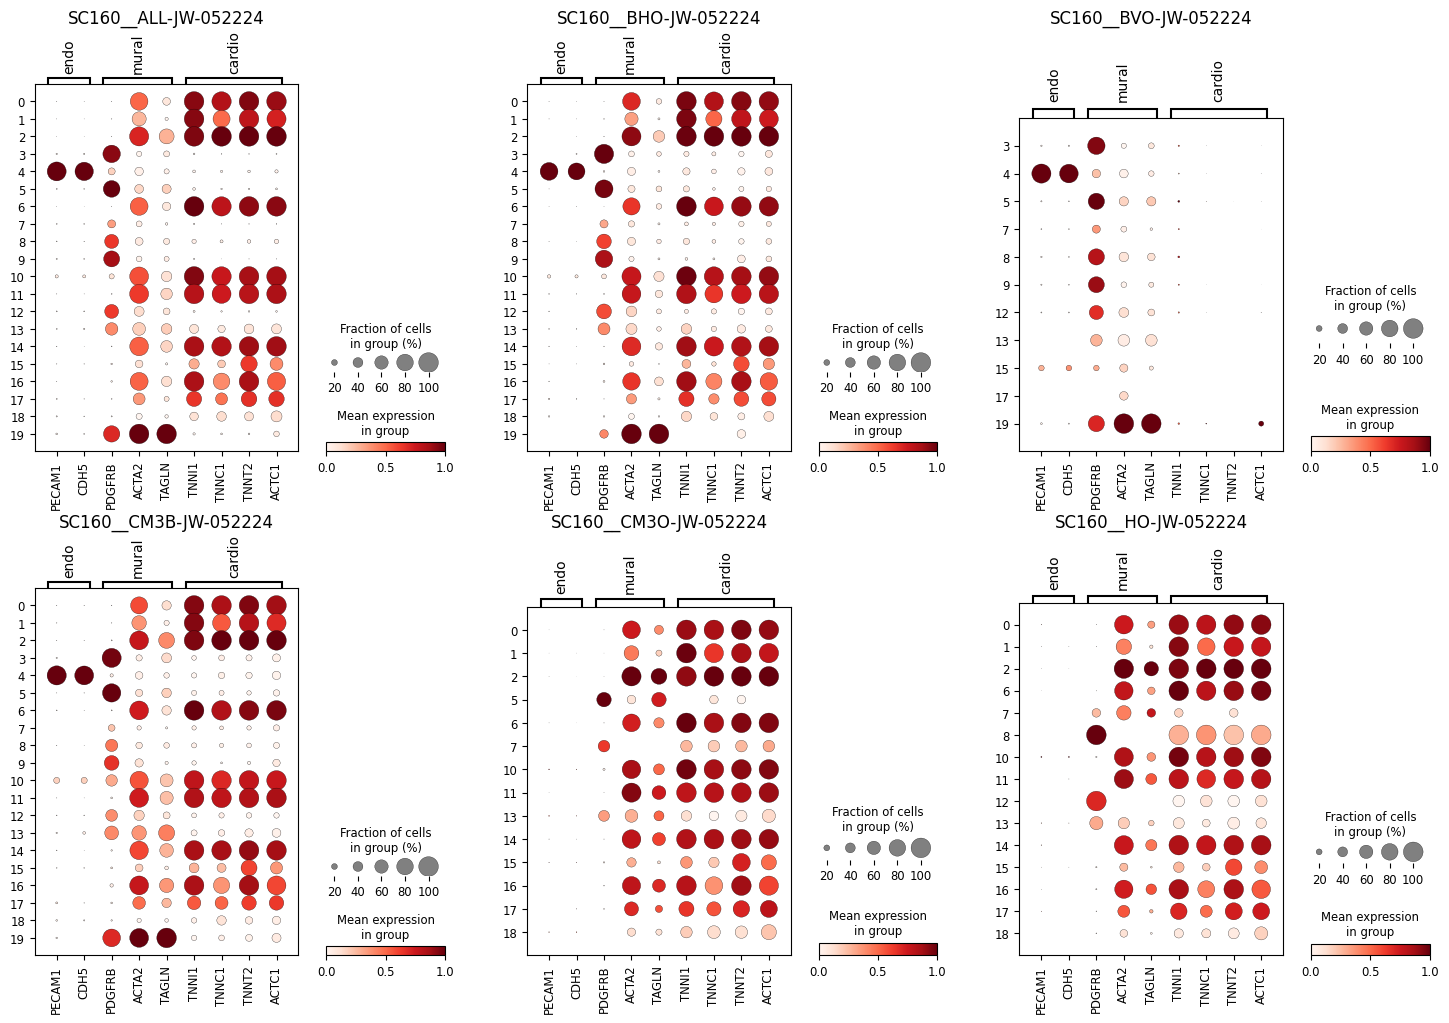

In [29]:
marker_dict = {
    'endo': ['PECAM1', 'CDH5'], 
    'mural': ['PDGFRB', 'ACTA2', 'TAGLN'], 
    'cardio': ['TNNI1', 'TNNC1', 'TNNT2', 'ACTC1'],
}

fig, axs = plt.subplots(2, 3, figsize=(18,12), layout="constrained")
axs = axs.flatten()
# axs[-1].remove()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/*.h5ad')):
    # try:
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, marker_dict, groupby="leiden", standard_scale="var", ax=axs[i], title=sample_name, show=False)
    # sc.pl.dotplot(adata, var_names=marker_genes, groupby='leiden', ax=axs[i], title=sample_name, show=False)
    # except:
    #     continue
    
plt.savefig(f'{WORK_DIR}/gene_marker_umap/dotplots.png')
plt.show()

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)
/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: N

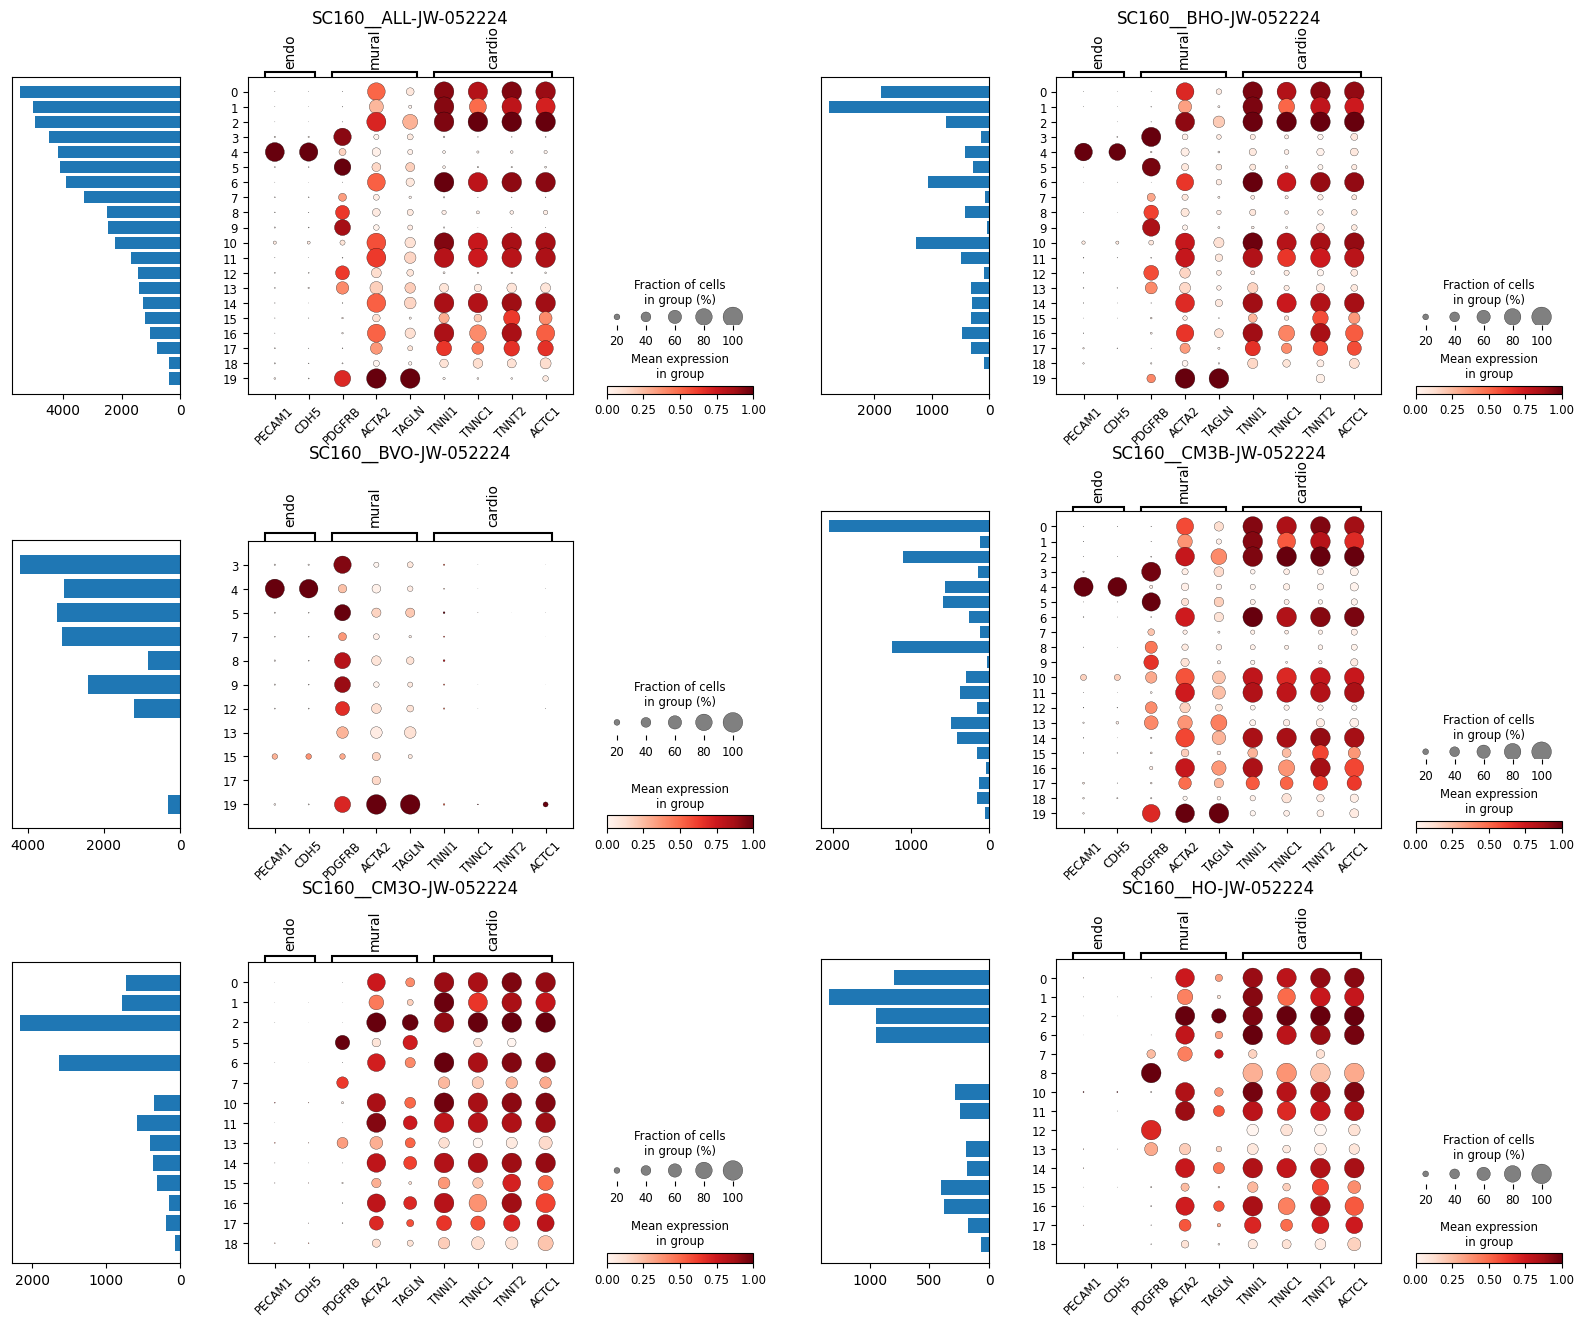

In [42]:
marker_dict = {
    'endo': ['PECAM1', 'CDH5'], 
    'mural': ['PDGFRB', 'ACTA2', 'TAGLN'], 
    'cardio': ['TNNI1', 'TNNC1', 'TNNT2', 'ACTC1'],
}

# fig, axs = plt.subplots(2, 6, figsize=(36,12), layout="constrained")
# axs = axs.flatten()
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 4, width_ratios=[1, 3, 1, 3])

# axs[-1].remove()

for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/*.h5ad')):
    
    sample_name = d1.split('/')[-1].strip('.h5ad')
    adata = sc.read_h5ad(d1)
    
    col = i%2
    row = int((i-col) / 2)
    
    ax1 = fig.add_subplot(gs[row, col*2])
    ax2 = fig.add_subplot(gs[row, col*2+1])
    
    # xlab = []
    dist = []
    for j in range(0, 20):
        if (adata.obs['leiden'] == str(j)).sum() > 0:
            # xlab.append(j)
            dist.append((adata.obs['leiden'] == str(j)).sum())
    # ax1.barh(xlab, dist)
    ax1.barh(range(0, len(dist)), dist)
    ax1.set_xlim(ax1.get_xlim()[1], ax1.get_xlim()[0])
    ax1.set_ylim(len(dist), -1)
    pos1 = ax1.get_position()
    if i in [0, 1, 3]:
        ax1.set_position([pos1.x0, pos1.y0, pos1.width, pos1.height * 0.875])
    elif i == 2:
        ax1.set_position([pos1.x0, pos1.y0, pos1.width, pos1.height * 0.795])
    elif i == 4:
        ax1.set_position([pos1.x0, pos1.y0, pos1.width, pos1.height * 0.83])
    elif i == 5:
        ax1.set_position([pos1.x0, pos1.y0, pos1.width, pos1.height * 0.84])
        
    ax1.set_yticks([])
    
    ax2 = sc.pl.dotplot(adata, marker_dict, groupby="leiden", standard_scale="var", ax=ax2, title=sample_name, show=False)
    ax2['mainplot_ax'].tick_params(axis='x', rotation=45)
    # sc.pl.dotplot(adata, var_names=marker_genes, groupby='leiden', ax=axs[i], title=sample_name, show=False)
    # except:
    #     continue
    
# plt.tight_layout()
plt.savefig(f'{WORK_DIR}/gene_marker_umap/dotplots_with_hist.png')
plt.show()

## 3. Label clusters

In [65]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/celltype_label

In [66]:
samples = ['BVO','HO','CM3O','BHO','CM3B']

celltypes_dict = {
    '0': 'cardio', 
    '1': 'cardio',
    '2': 'cardio',
    '3': 'mural',
    '4': 'endo',
    '5': 'mural',
    '6': 'cardio',
    '7': 'other',
    '8': 'mural',
    '9': 'mural',
    '10': 'cardio',
    '11': 'cardio',
    '12': 'mural',
    '13': 'mural',
    '14': 'cardio',
    '15': 'cardio',
    '16': 'cardio',
    '17': 'cardio',
    '18': 'other',
    '19': 'mural',
}

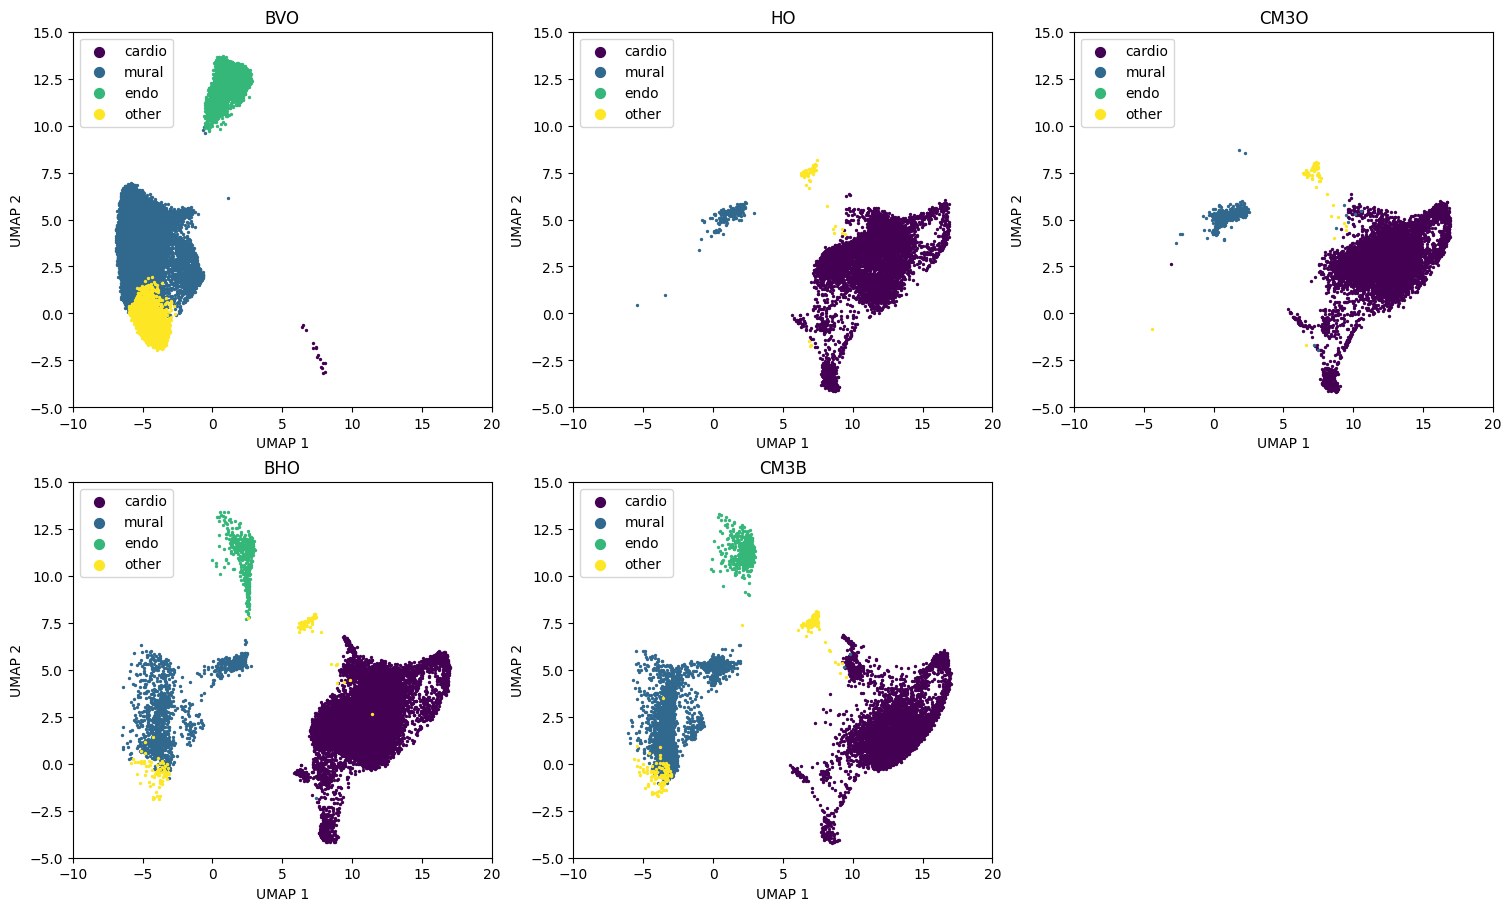

In [67]:
fig, axs = plt.subplots(2, 3, figsize=(15,9), layout="constrained")
axs = axs.flatten()
axs[-1].remove()

cell_types = ['cardio','mural','endo','other']
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, len(cell_types)))

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/SC160__{sample}-JW-052224.h5ad')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
    adata.write(f'{WORK_DIR}/celltype_label/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colors[j], s=2)
        
    axs[i].legend(loc='upper left', markerscale=5)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-10, 20])
    axs[i].set_ylim([-5, 15])
    
plt.savefig(f'{WORK_DIR}/celltype_label/umap.png')
plt.show()

## 4. Differential Expresssion

In [68]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO05/volcano

In [69]:
adata_BVO = sc.read_h5ad(f'{WORK_DIR}/celltype_label/BVO.h5ad')
adata_HO = sc.read_h5ad(f'{WORK_DIR}/celltype_label/HO.h5ad')
adata_CM3O = sc.read_h5ad(f'{WORK_DIR}/celltype_label/CM3O.h5ad')
adata_BHO = sc.read_h5ad(f'{WORK_DIR}/celltype_label/BHO.h5ad')
adata_CM3B = sc.read_h5ad(f'{WORK_DIR}/celltype_label/CM3B.h5ad')

In [70]:
def volcano_plot(adata1, adata2, celltype, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 1.5
    pvalue_thres = 5
    
    if np.any(adata1.var_names != adata2.var_names):
        raise ValueError('adata var names not unified')
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X[adata1.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT
    data2 = adata2.X[adata2.obs['cell_type'] == celltype, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
    plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

### 4.1 mural cell

/tmp/ipykernel_2293369/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


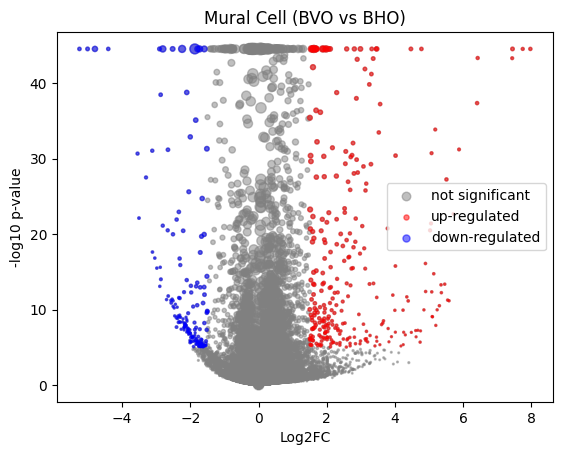

In [71]:
volcano_plot(adata_BVO, 
             adata_BHO, 
             'mural', 
             'Mural Cell (BVO vs BHO)', 
             save=f'{WORK_DIR}/volcano/mural.BVO.BHO.png', 
             save_tsv=f'{WORK_DIR}/volcano/mural.BVO.BHO.tsv')

/tmp/ipykernel_2293369/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


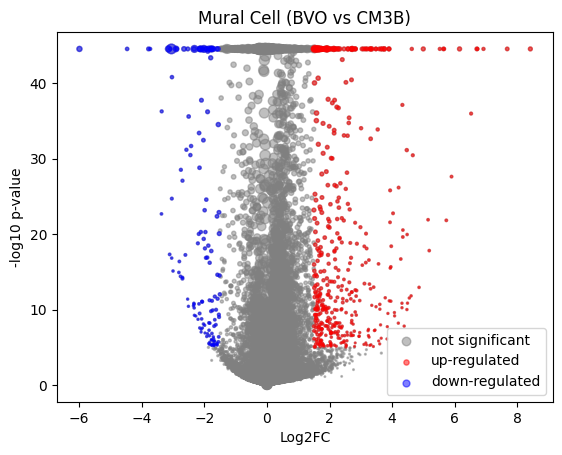

In [72]:
volcano_plot(adata_BVO, 
             adata_CM3B, 
             'mural', 
             'Mural Cell (BVO vs CM3B)', 
             save=f'{WORK_DIR}/volcano/mural.BVO.CM3B.png', 
             save_tsv=f'{WORK_DIR}/volcano/mural.BVO.CM3B.tsv')

/tmp/ipykernel_2293369/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


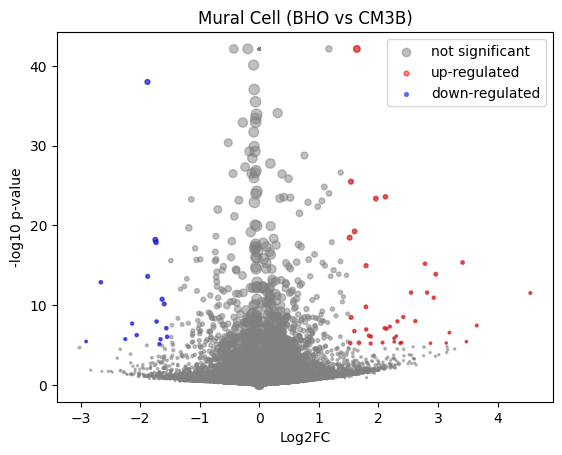

In [73]:
volcano_plot(adata_BHO, 
             adata_CM3B, 
             'mural', 
             'Mural Cell (BHO vs CM3B)', 
             save=f'{WORK_DIR}/volcano/mural.BHO.CM3B.png', 
             save_tsv=f'{WORK_DIR}/volcano/mural.BHO.CM3B.tsv')

### 4.2 endothelial cell

/tmp/ipykernel_2293369/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


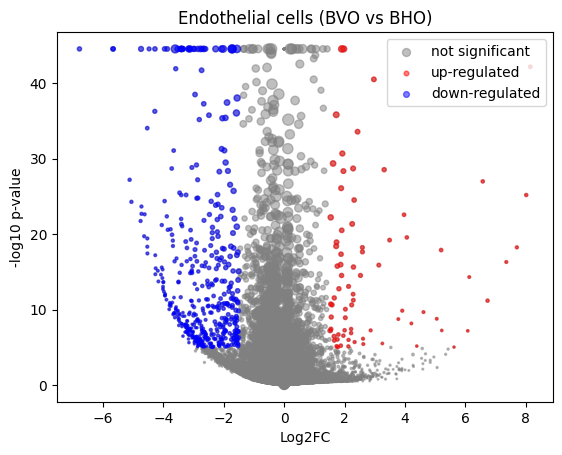

In [74]:
volcano_plot(adata_BVO, 
             adata_BHO, 
             'endo', 
             'Endothelial cells (BVO vs BHO)', 
             save=f'{WORK_DIR}/volcano/endo.BVO.BHO.png', 
             save_tsv=f'{WORK_DIR}/volcano/endo.BVO.BHO.tsv')

/tmp/ipykernel_2293369/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


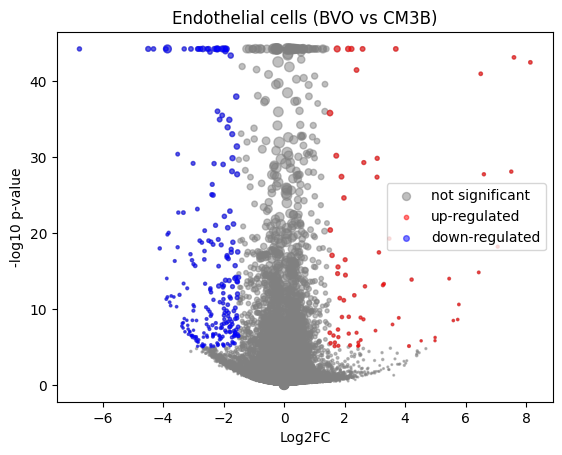

In [75]:
volcano_plot(adata_BVO, 
             adata_CM3B, 
             'endo', 
             'Endothelial cells (BVO vs CM3B)', 
             save=f'{WORK_DIR}/volcano/endo.BVO.CM3B.png', 
             save_tsv=f'{WORK_DIR}/volcano/endo.BVO.CM3B.tsv')

/tmp/ipykernel_2293369/728440560.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(


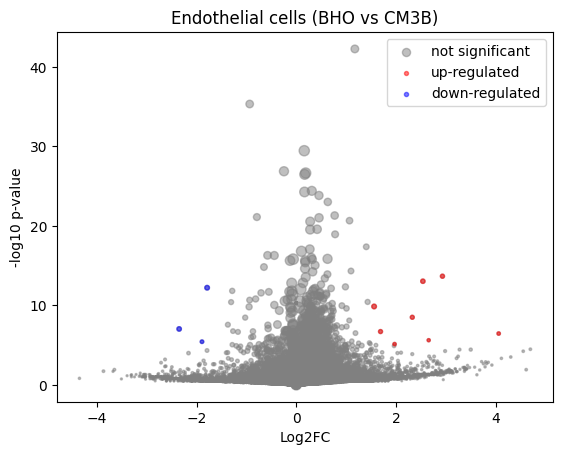

In [76]:
volcano_plot(adata_BHO, 
             adata_CM3B, 
             'endo', 
             'Endothelial cells (BHO vs CM3B)', 
             save=f'{WORK_DIR}/volcano/endo.BHO.CM3B.png', 
             save_tsv=f'{WORK_DIR}/volcano/endo.BHO.CM3B.tsv')

### 4.3 cardiomyocyte

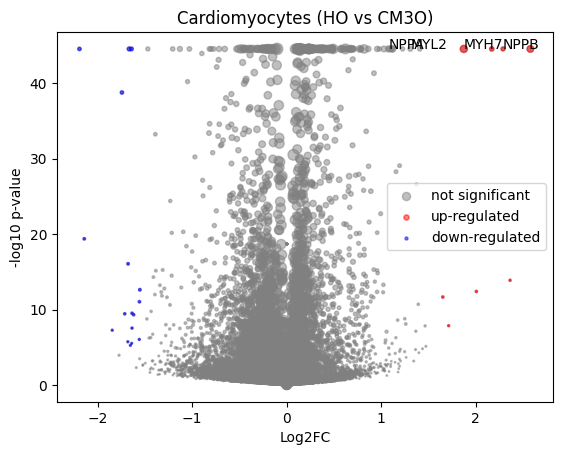

In [77]:
volcano_plot(adata_HO, 
             adata_CM3O, 
             'cardio', 
             'Cardiomyocytes (HO vs CM3O)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{WORK_DIR}/volcano/cardio.HO.CM3O.png', 
             save_tsv=f'{WORK_DIR}/volcano/cardio.HO.CM3O.tsv')

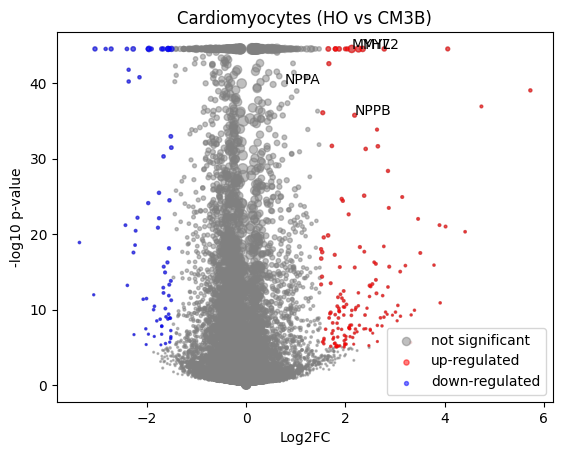

In [78]:
volcano_plot(adata_HO, 
             adata_CM3B, 
             'cardio', 
             'Cardiomyocytes (HO vs CM3B)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{WORK_DIR}/volcano/cardio.HO.CM3B.png', 
             save_tsv=f'{WORK_DIR}/volcano/cardio.HO.CM3B.tsv')

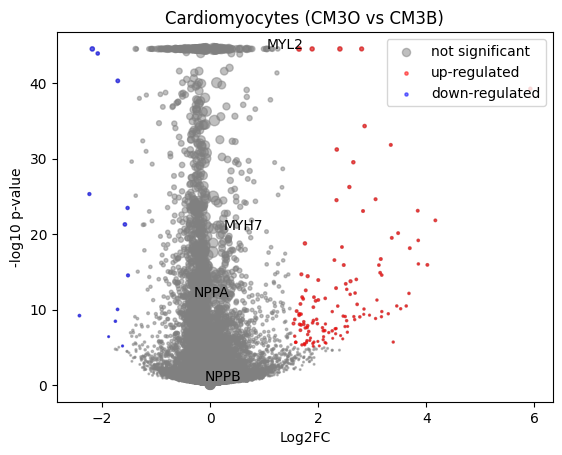

False Positive Rate: 0.004043605365973607


In [79]:
volcano_plot(adata_CM3O, 
             adata_CM3B, 
             'cardio', 
             'Cardiomyocytes (CM3O vs CM3B)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{WORK_DIR}/volcano/cardio.CM3O.CM3B.png', 
             save_tsv=f'{WORK_DIR}/volcano/cardio.CM3O.CM3B.tsv')

df_deg = pd.read_csv('~/PyProjects/cocultured_organ/workspace/CCO04/volcano/cardio.CM3O.CM3B.deg.tsv')
df_all = pd.read_csv('~/PyProjects/cocultured_organ/workspace/CCO04/volcano/cardio.CM3O.CM3B.tsv')
print(f'False Positive Rate: {len(df_deg) / len(df_all)}')

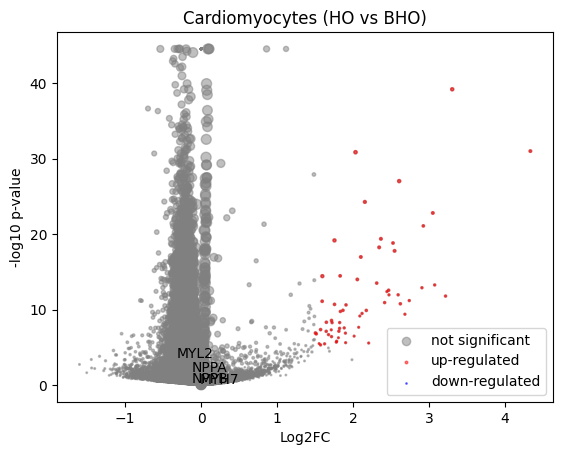

In [80]:
volcano_plot(adata_HO, 
             adata_BHO, 
             'cardio', 
             'Cardiomyocytes (HO vs BHO)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{WORK_DIR}/volcano/cardio.HO.BHO.png', 
             save_tsv=f'{WORK_DIR}/volcano/cardio.HO.BHO.tsv')

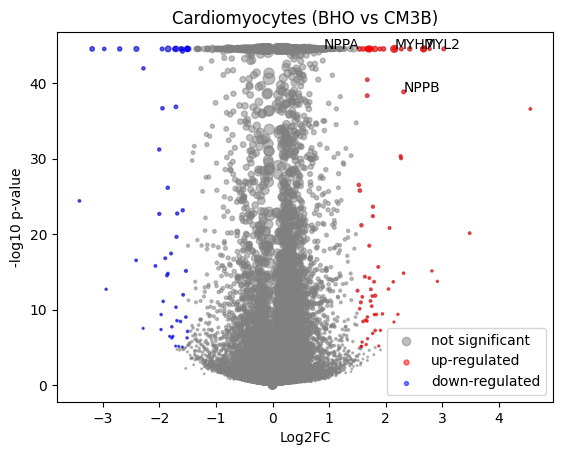

In [81]:
volcano_plot(adata_BHO, 
             adata_CM3B, 
             'cardio', 
             'Cardiomyocytes (BHO vs CM3B)', 
             ['NPPA','NPPB','MYH7','MYL2'], 
             save=f'{WORK_DIR}/volcano/cardio.BHO.CM3B.png', 
             save_tsv=f'{WORK_DIR}/volcano/cardio.BHO.CM3B.tsv')

### 4.4 visualize maturation

In [82]:
celltypes_dict = {
    '0': 'cardio', 
    '1': 'cardio',
    '2': 'cardio',
    '3': 'peri',
    '4': 'endo',
    '5': 'peri',
    '6': 'cardio',
    '7': 'other',
    '8': 'other',
    '9': 'peri',
    '10': 'cardio',
    '11': 'cardio',
    '12': 'other',
    '13': 'other',
    '14': 'cardio',
    '15': 'other',
    '16': 'cardio',
    '17': 'cardio',
    '18': 'other',
    '19': 'peri',
}
samples = [adata_BVO, adata_HO, adata_CM3O, adata_BHO, adata_CM3B]

In [84]:
hm

array([[0.45204198, 0.        , 0.        , 0.        ],
       [3.42073441, 0.        , 0.        , 0.        ],
       [3.59301162, 0.        , 0.        , 0.        ],
       [3.56101251, 0.        , 0.        , 0.        ],
       [0.28007707, 0.        , 0.        , 0.        ],
       [2.01557946, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [1.47222257, 0.        , 0.        , 0.        ],
       [0.08326907, 0.        , 0.        , 0.        ],
       [0.12786964, 0.        , 0.        , 0.        ]])

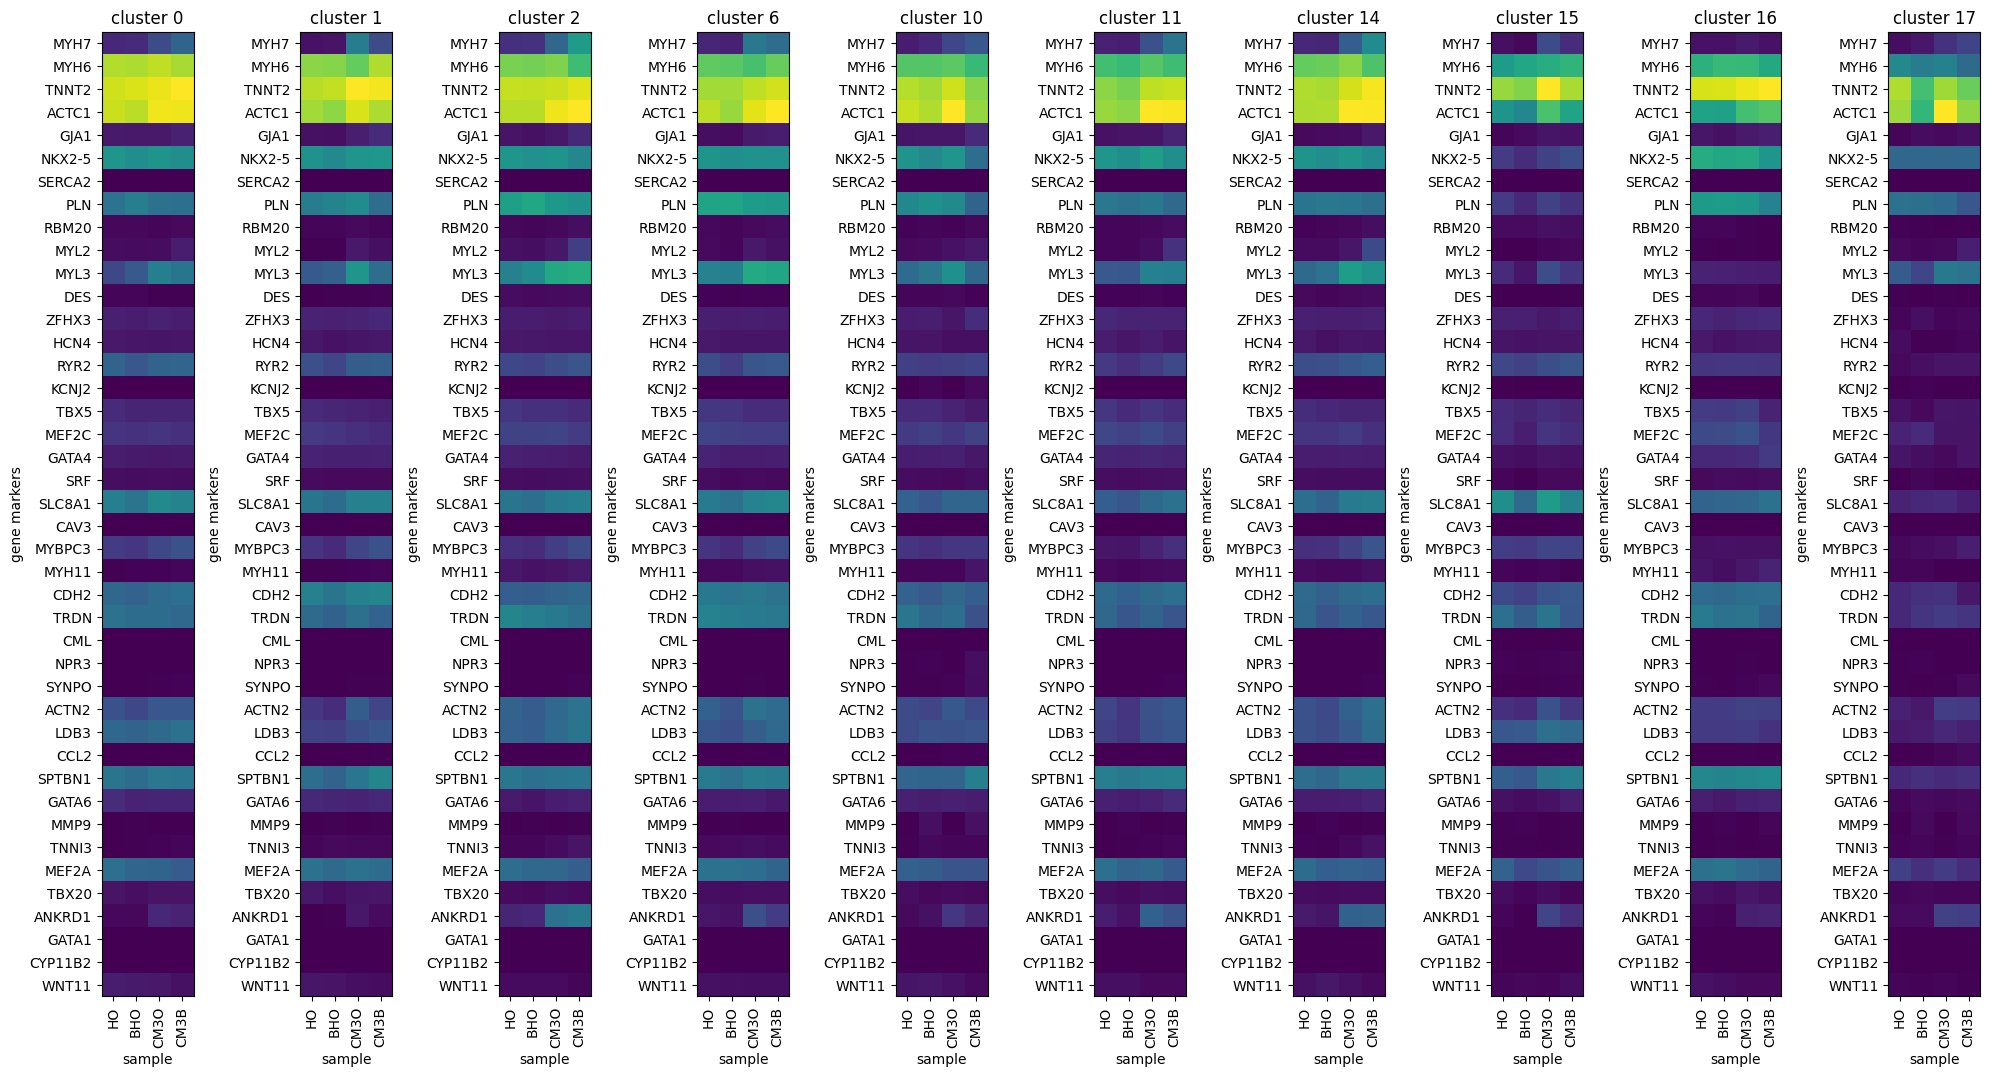

In [89]:
samples = [adata_HO, adata_BHO, adata_CM3O, adata_CM3B]
clusters = ['0', '1', '2', '6', '10', '11', '14', '15', '16', '17']
genes_markers = ['MYH7', 'MYH6', 'TNNT2', 'ACTC1', 'GJA1', 'NKX2-5', 'SERCA2', 'PLN', 'RBM20', 'MYL2', 'MYL3', 'DES', 'ZFHX3', 'HCN4', 'RYR2', 
                 'KCNJ2', 'TBX5', 'MEF2C', 'GATA4', 'SRF', 'SLC8A1', 'CAV3', 'MYBPC3', 'MYH11', 'CDH2', 'TRDN', 'CML', 'NPR3', 'SYNPO', 'ACTN2', 
                 'LDB3', 'CCL2', 'SPTBN1', 'GATA6', 'MMP9', 'TNNI3', 'MEF2A', 'TBX20', 'ANKRD1', 'GATA1', 'CYP11B2', 'WNT11']
sample_names = ['HO','BHO','CM3O','CM3B']

fig, axs = plt.subplots(1, 10, figsize=(20, 20))

for k, cluster in enumerate(clusters):

    hm = np.zeros((len(genes_markers), len(samples)))

    for i, adata in enumerate(samples):
        for j, gene in enumerate(genes_markers):
            hm[j, i] = adata[adata.obs['leiden'] == cluster][:, adata.var_names == gene].X.mean()

    axs[k].imshow(hm)
    axs[k].set_title(f"cluster {cluster}")
    axs[k].set_xticks(ticks=range(0, 4), labels=sample_names, rotation=90)
    axs[k].set_yticks(ticks=range(0, len(genes_markers)), labels=genes_markers)
    axs[k].set_xlabel('sample')
    axs[k].set_ylabel('gene markers')
    # axs[k].set_colorbar()
    
plt.tight_layout()
plt.show()